### Question: When does each region of the world cross 2°C of warming under different climate scenarios? OR How does the timing of crossing critical warming thresholds (such as 2°C) vary across regions and emissions scenarios?

- where does warming happen first?
- when does each place reach +2°C?
- how does that change depending on emissions?

Rationale:
- warming is not uniform across the globe and different regions reach key warming thresholds at different times
- this makes threshold-based analysis more informative than just looking at raw temperature values
- spatial: different regions behave differently
- temporal: crossing happens at different years
- interactive
  - different thresholds
  - different scenarios (ssp126 vs ssp585)

NOTE: We are currently working with the SSP585 future scenario, which spans from 2015 to 2100. Since this dataset does not include historical data, we temporarily define out baseline using earlier years in the dataset. For our final submission, we plan to incorporate historical data to compute a more accurate baseline.

In [1]:
! pip install --upgrade xarray zarr gcsfs cftime nc-time-axis


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import zarr
import gcsfs

xr.set_options(display_style='html')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [3]:
plt.rcParams['figure.figsize'] = 12, 6

In [4]:
url = 'https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv'
catalog = pd.read_csv(url)
catalog.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,ps,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
1,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rsds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
2,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlus,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
3,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
4,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,psl,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706


## Filter to temperature data

In [5]:
subset = catalog.query(
    "variable_id == 'tas' and "
    "table_id == 'Amon' and "
    "experiment_id == 'ssp585' and "
    "source_id == 'CESM2'"
)
subset

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
444816,ScenarioMIP,NCAR,CESM2,ssp585,r11i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/ScenarioMIP/NCAR/CESM2/ssp585...,NaN,20200528
444904,ScenarioMIP,NCAR,CESM2,ssp585,r4i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/ScenarioMIP/NCAR/CESM2/ssp585...,NaN,20200528
445756,ScenarioMIP,NCAR,CESM2,ssp585,r10i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/ScenarioMIP/NCAR/CESM2/ssp585...,NaN,20200528


In [6]:
# this only needs to be created once
gcs = gcsfs.GCSFileSystem(token='anon')

# get the path to a specific zarr store (the first one from the dataframe above)
zstore = subset.iloc[0]['zstore']

# create a mutable-mapping-style interface to the store
mapper = gcs.get_mapper(zstore)

# open it using xarray and zarr
ds = xr.open_zarr(mapper, consolidated=True)
ds

I0510 15:35:26.094991  441362 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0510 15:35:26.112958  441380 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(103, generation: 1)
I0510 15:35:26.113083  441380 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(103, generation: 1)
I0510 15:35:26.113106  441380 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(103, generation: 1)
I0510 15:35:26.113107  441380 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(103, generation: 1)
I0510 15:35:26.113109  441380 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(103, generation: 1)
I0510 15:35:26.113110  441380 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(103, generation: 1)
I0510 15:35:26.113113  441380 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(103, generation: 1)
I0510 15:35:26.113115  441380 ev_poll_posix.cc:593] FD from fork parent sti

<xarray.Dataset> Size: 228MB
Dimensions:    (time: 1032, lat: 192, lon: 288, nbnd: 2)
Coordinates:
  * time       (time) object 8kB 2015-01-15 12:00:00 ... 2100-12-15 12:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
    lat_bnds   (lat, nbnd) float64 3kB ...
    lon_bnds   (lon, nbnd) float64 5kB ...
    time_bnds  (time, nbnd) object 17kB ...
Dimensions without coordinates: nbnd
Data variables:
    tas        (time, lat, lon) float32 228MB ...
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   735110.0
    branch_time_in_parent:  735110.0
    case_id:                1734
    ...                     ...
    sub_experiment_id:      none
    table_id:               Amon
    tracking_id:            hdl:21.14100/59108111-cdc4-41f4-a545-c95fc968c977...
    variable_id:            tas
    variant_info:           CMIP6 SSP5-8.5 experiments (2015-2100) with CAM6,...
    variant_label:          r11i1p1f1

In [7]:
tas_c = ds['tas'] - 273.15
tas_c

<xarray.DataArray 'tas' (time: 1032, lat: 192, lon: 288)> Size: 228MB
array([[[-25.048706  , -25.048706  , -25.048706  , ..., -25.048706  ,
         -25.048706  , -25.048706  ],
        [-24.116898  , -24.159271  , -24.320068  , ..., -24.066666  ,
         -24.079361  , -24.097641  ],
        [-23.685196  , -23.73198   , -23.76155   , ..., -23.446045  ,
         -23.49739   , -23.571503  ],
        ...,
        [-26.532043  , -26.525024  , -26.518082  , ..., -26.560379  ,
         -26.551727  , -26.542206  ],
        [-25.977188  , -25.976028  , -25.974564  , ..., -25.977966  ,
         -25.977448  , -25.97754   ],
        [-25.5746    , -25.575104  , -25.575562  , ..., -25.572739  ,
         -25.573425  , -25.574036  ]],

       [[-36.08696   , -36.08696   , -36.08696   , ..., -36.08696   ,
         -36.08696   , -36.08696   ],
        [-35.61508   , -35.658096  , -35.812958  , ..., -35.61351   ,
         -35.609726  , -35.613785  ],
        [-35.163208  , -35.232864  , -35.25911   , ..., -34.921814  ,
         -34.975266  , -35.0542    ],
...
          -0.6880188 ,  -0.6831665 ],
        [ -0.64260864,  -0.64071655,  -0.6385498 , ...,  -0.648468  ,
          -0.64627075,  -0.6444397 ],
        [ -0.5538635 ,  -0.55404663,  -0.5541992 , ...,  -0.55322266,
          -0.5534668 ,  -0.5536804 ]],

       [[-17.461075  , -17.461075  , -17.461075  , ..., -17.461075  ,
         -17.461075  , -17.461075  ],
        [-16.923218  , -16.958282  , -17.11139   , ..., -16.89917   ,
         -16.901611  , -16.913147  ],
        [-16.69571   , -16.7294    , -16.747253  , ..., -16.470917  ,
         -16.519684  , -16.590729  ],
        ...,
        [ -1.5248413 ,  -1.5194397 ,  -1.5140686 , ...,  -1.5395813 ,
          -1.534729  ,  -1.5299988 ],
        [ -1.5227356 ,  -1.519989  ,  -1.5171204 , ...,  -1.5314941 ,
          -1.5284424 ,  -1.5255432 ],
        [ -1.5210876 ,  -1.5209961 ,  -1.5209045 , ...,  -1.5213928 ,
          -1.5212708 ,  -1.5211792 ]]],
      shape=(1032, 192, 288), dtype=float32)
Coordinates:
  * time     (time) object 8kB 2015-01-15 12:00:00 ... 2100-12-15 12:00:00
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Attributes: (12/19)
    cell_measures:  area: areacella
    cell_methods:   area: time: mean
    comment:        TREFHT
    description:    near-surface (usually, 2 meter) air temperature
    frequency:      mon
    id:             tas
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Near-Surface Air Temperature
    type:           real
    units:          K
    variable_id:    tas

In [8]:
ds['time'].values[0]

cftime.DatetimeNoLeap(2015, 1, 15, 12, 0, 0, 0, has_year_zero=True)

In [9]:
ds['time'].values[-1]

cftime.DatetimeNoLeap(2100, 12, 15, 12, 0, 0, 0, has_year_zero=True)

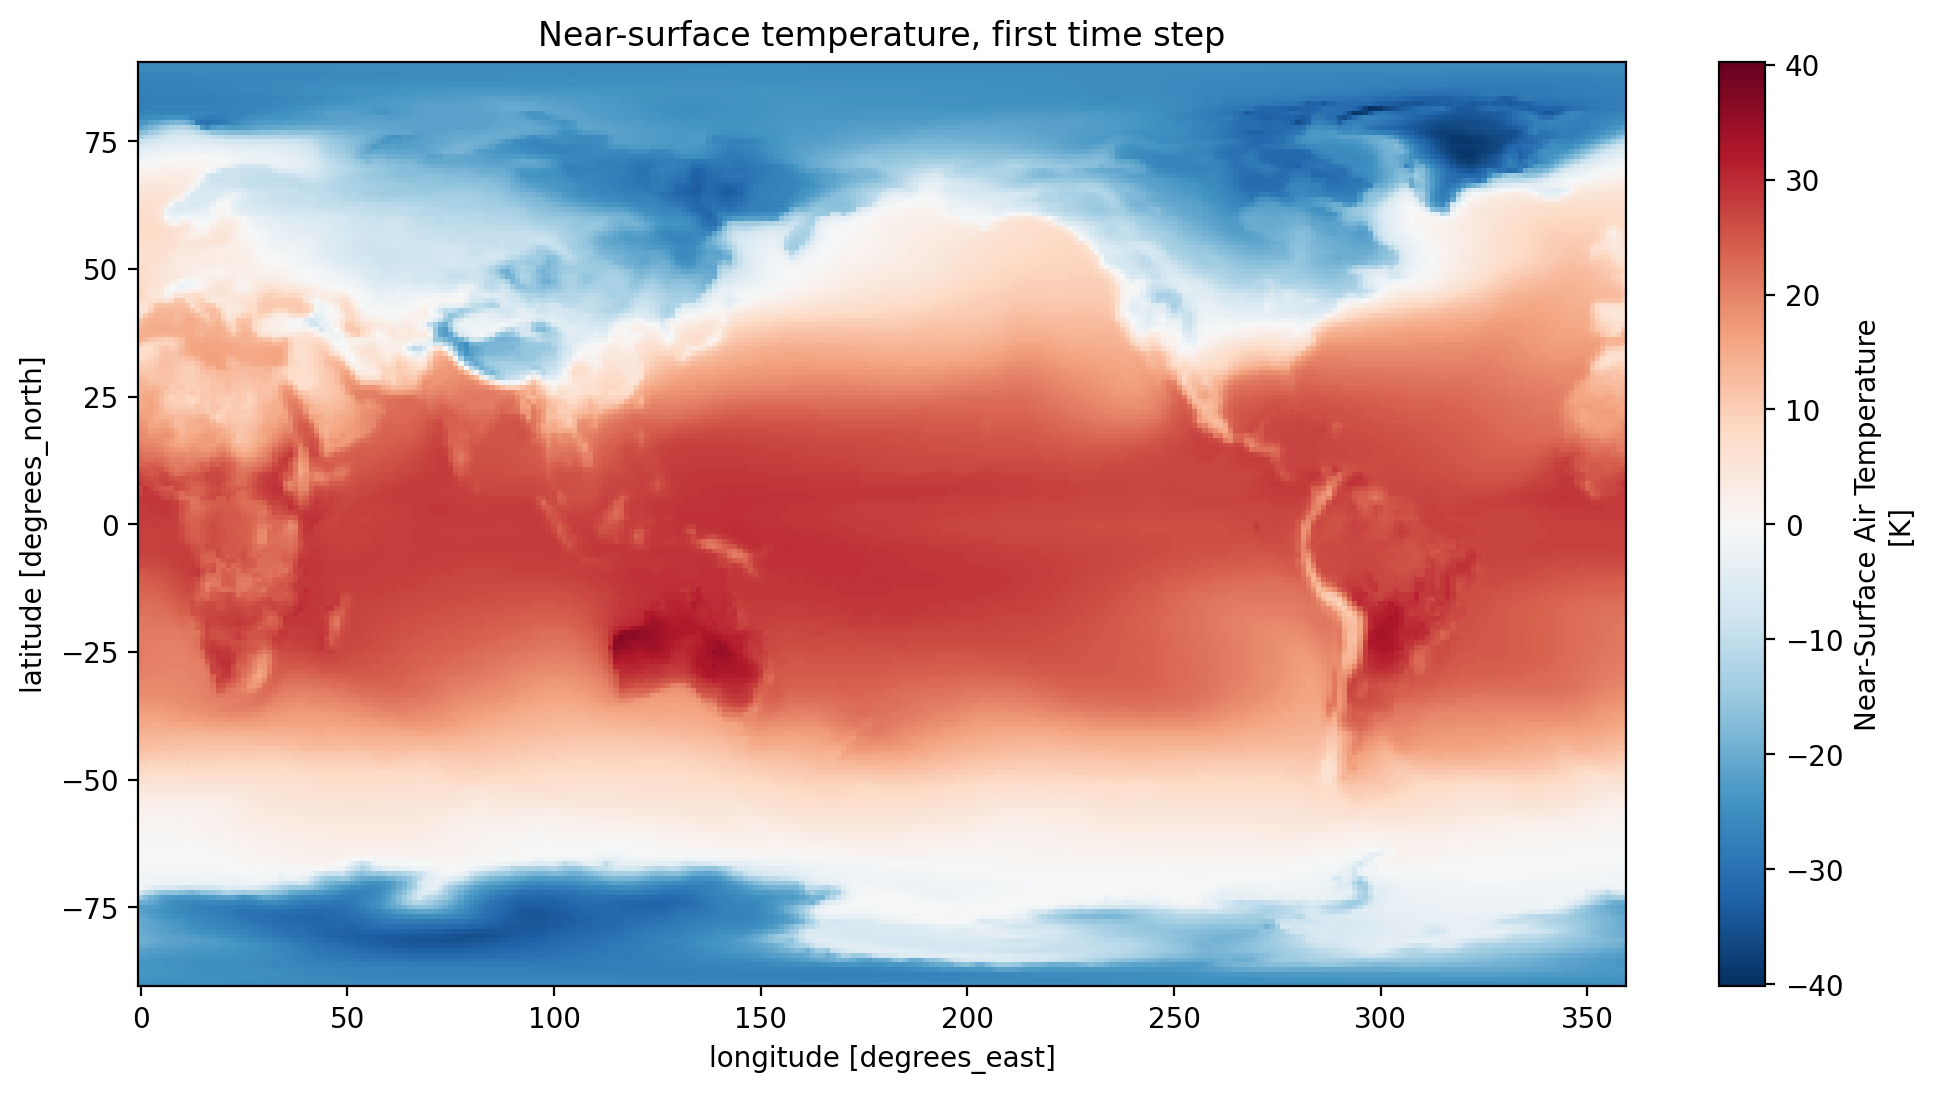

In [10]:
tas_c.isel(time=0).plot()
plt.title("Near-surface temperature, first time step")
plt.show()

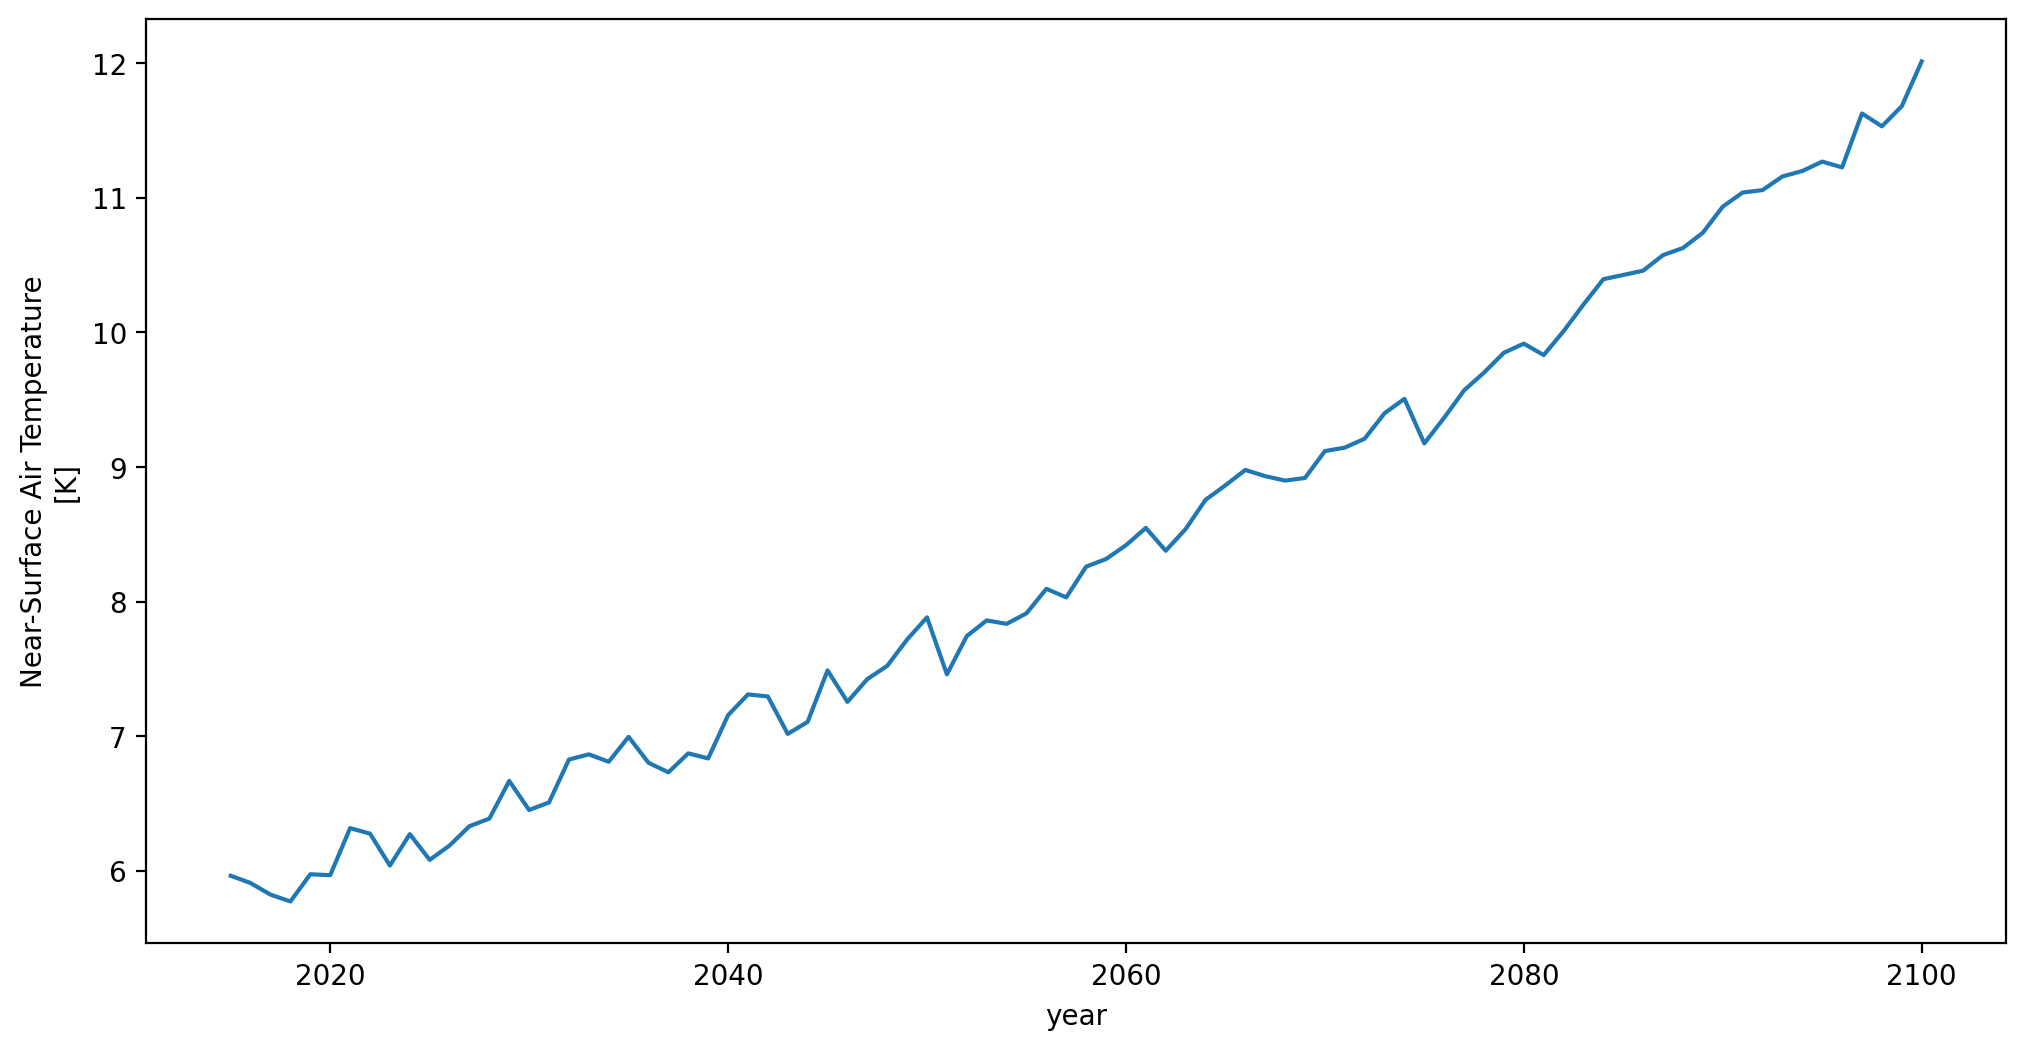

In [11]:
tas_yearly = tas_c.groupby("time.year").mean("time")
tas_yearly.mean(dim=["lat", "lon"]).plot()
plt.show()

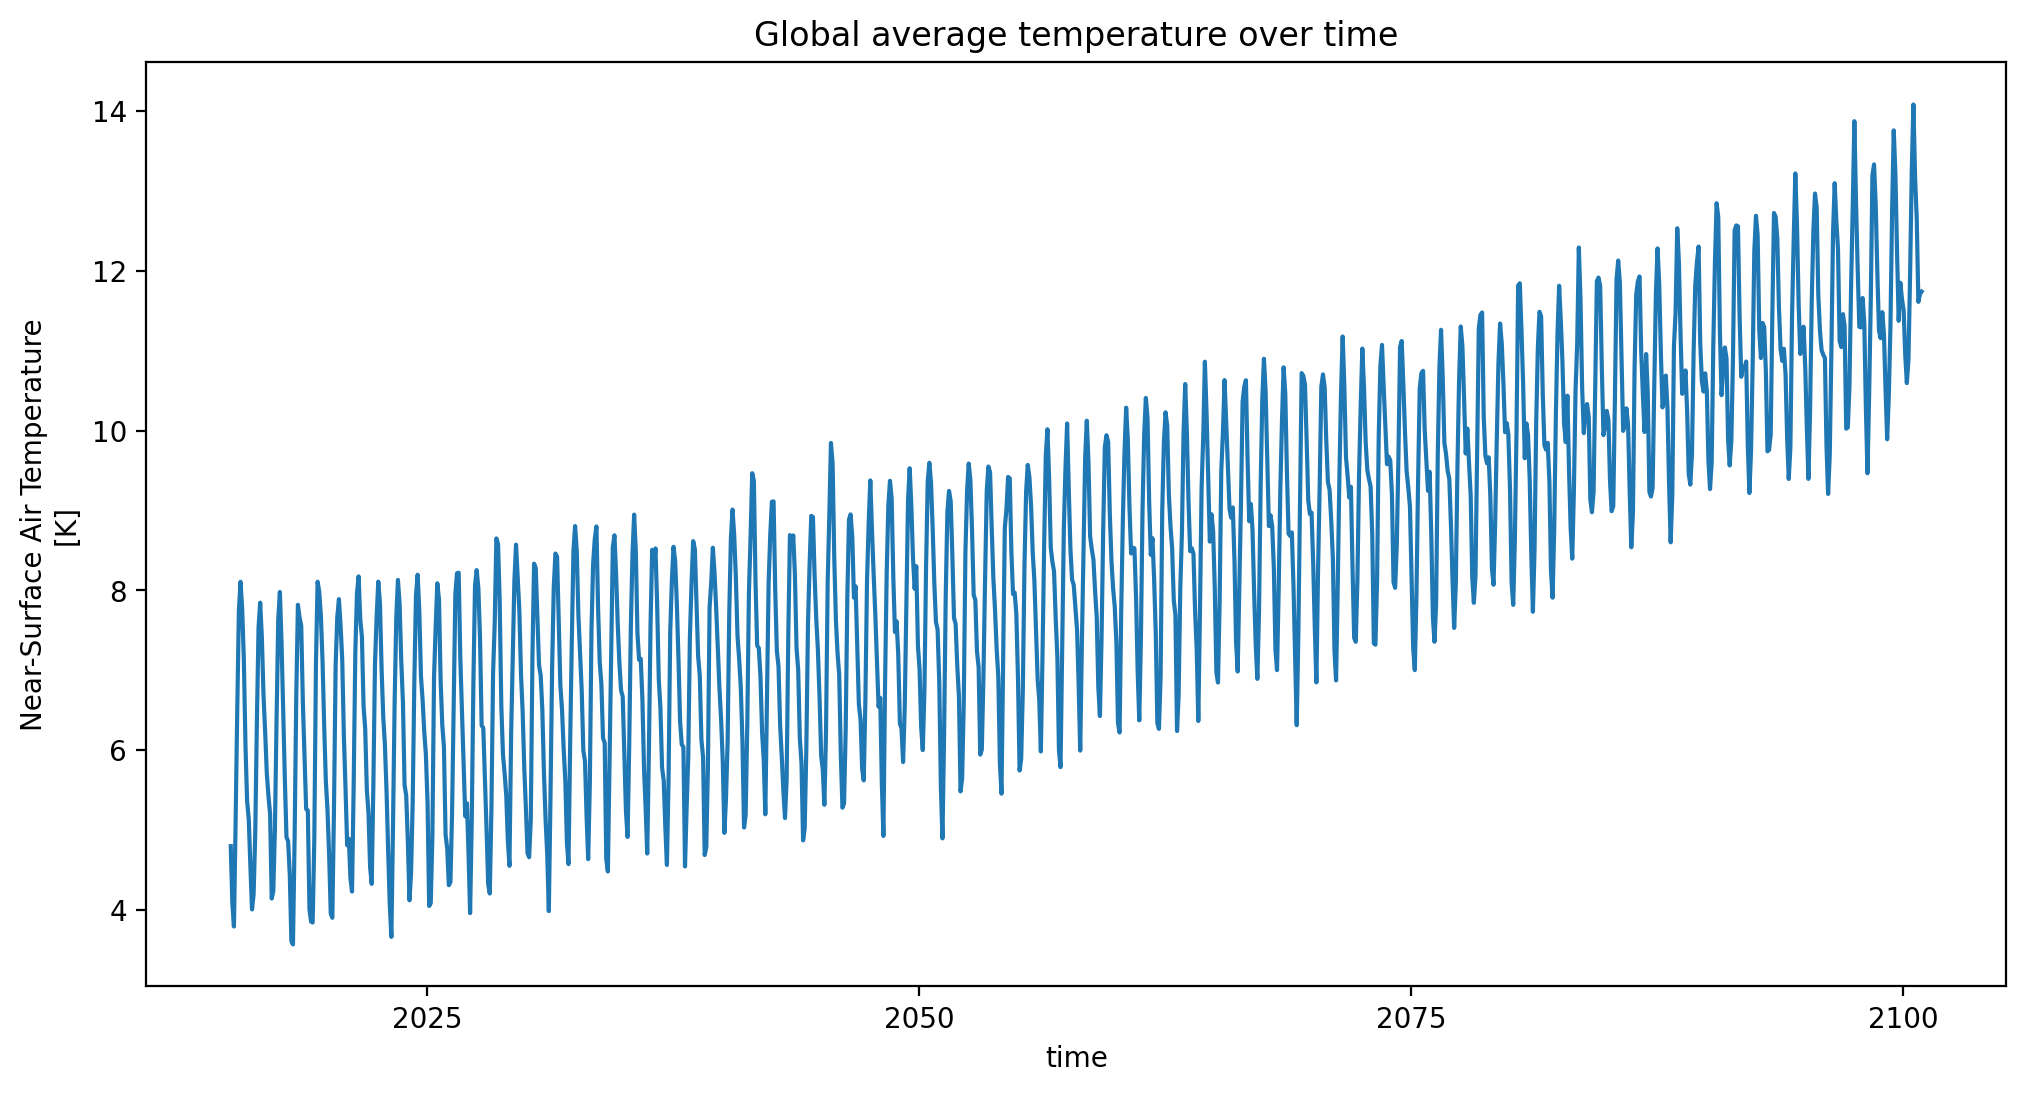

In [12]:
tas_c.mean(dim=["lat", "lon"]).plot()
plt.title("Global average temperature over time")
plt.show()

In [13]:
tas_yearly = tas_c.groupby("time.year").mean("time")

baseline = tas_yearly.sel(year=slice(2015, 2034)).mean("year")

anomaly = tas_yearly - baseline

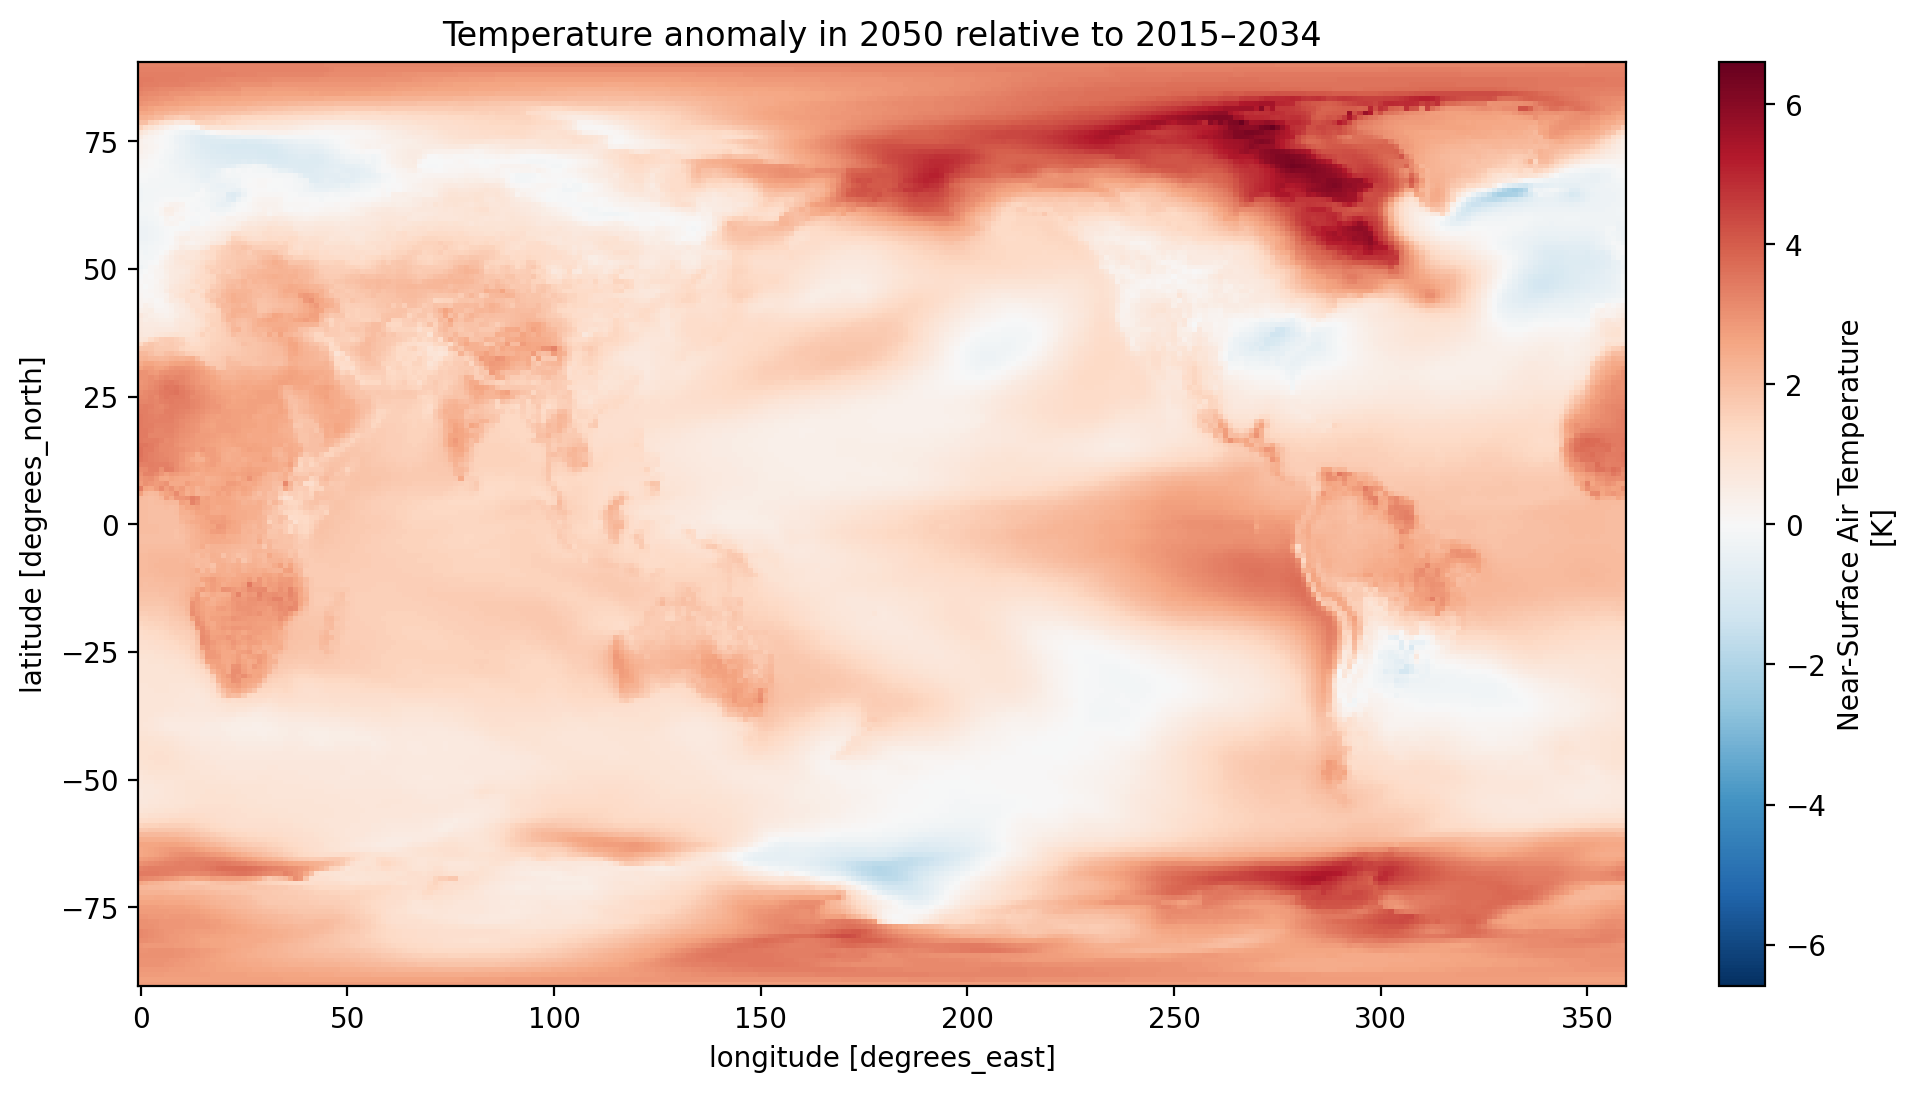

In [14]:
anomaly.sel(year=2050).plot()
plt.title("Temperature anomaly in 2050 relative to 2015–2034")
plt.show()

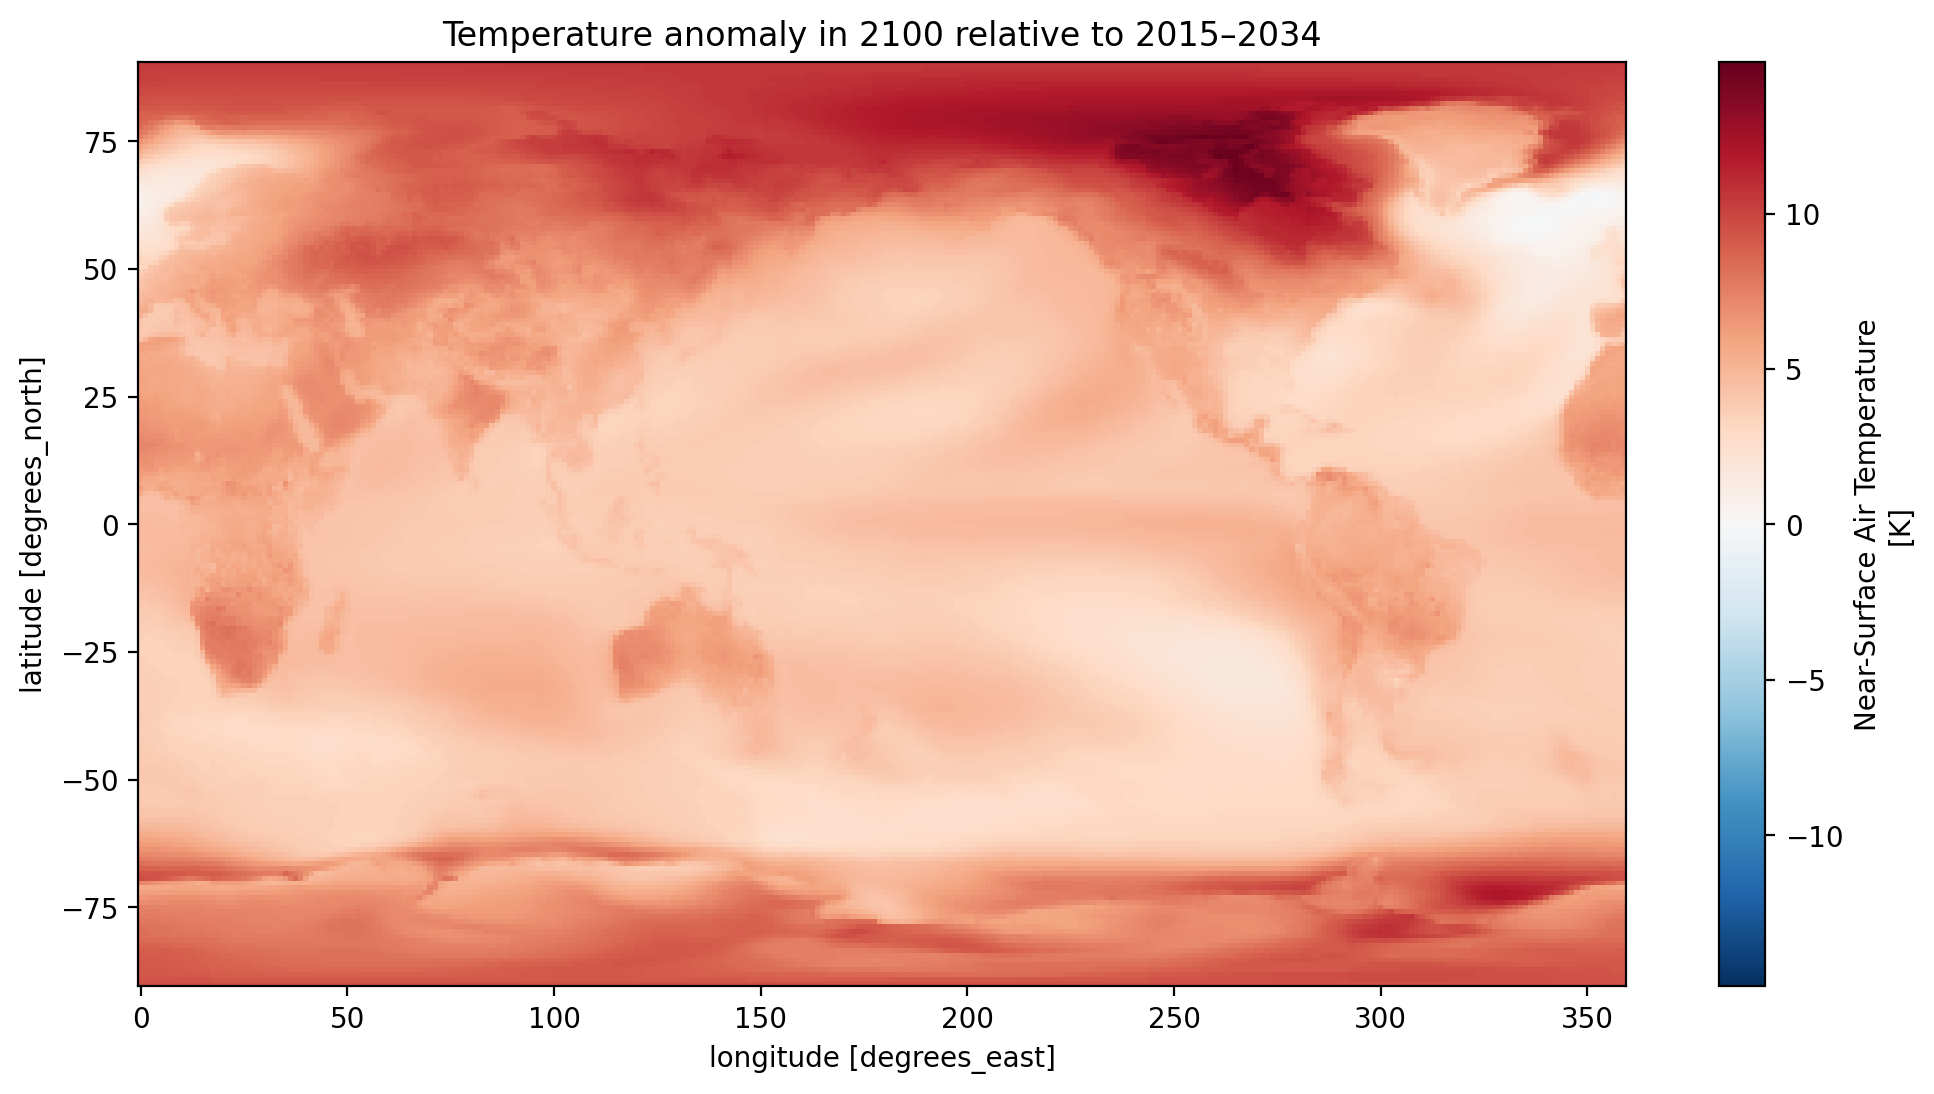

In [15]:
anomaly.sel(year=2100).plot()
plt.title("Temperature anomaly in 2100 relative to 2015–2034")
plt.show()

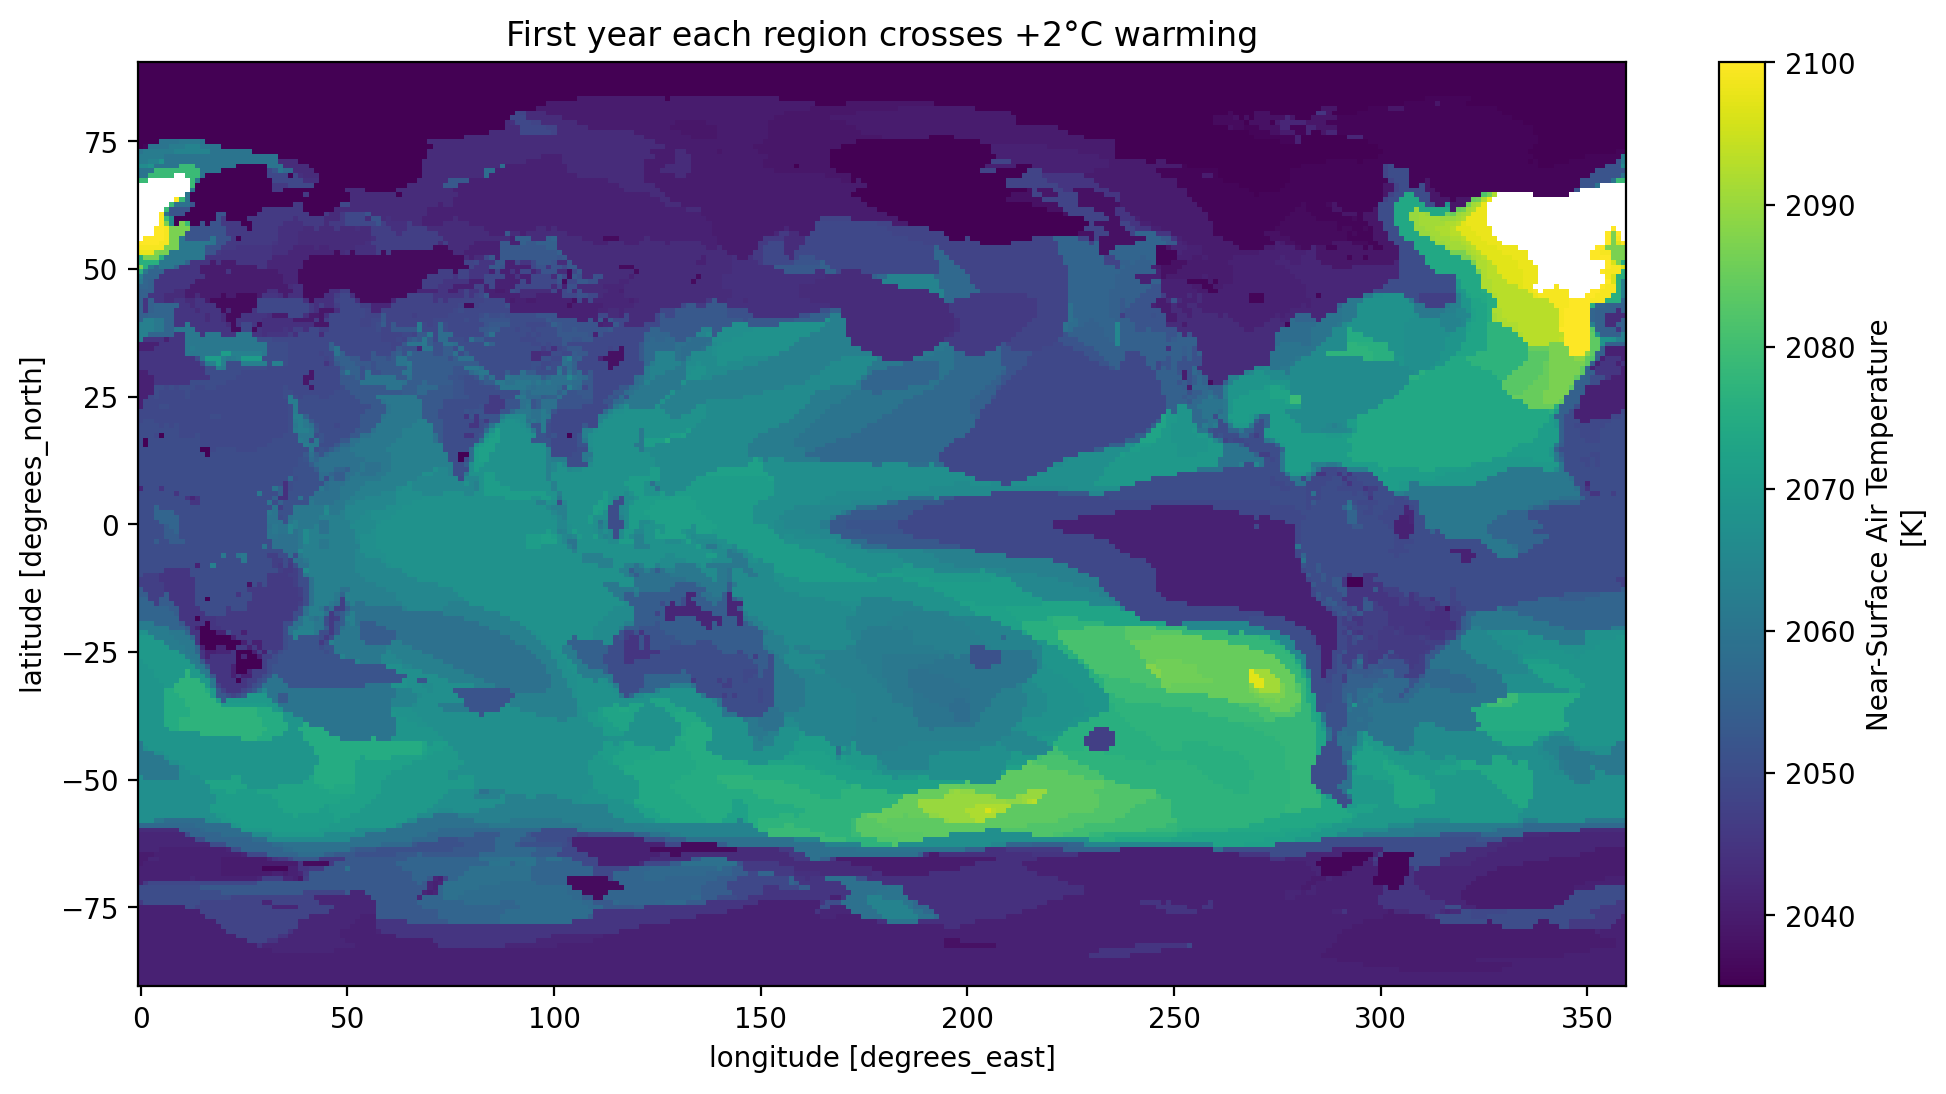

In [16]:
future = anomaly.sel(year=slice(2035, 2100))

crossed = future >= 2
ever_crossed = crossed.any("year")

first_crossing = crossed.idxmax("year")
first_crossing = first_crossing.where(ever_crossed)

first_crossing.plot()
plt.title("First year each region crosses +2°C warming")
plt.show()

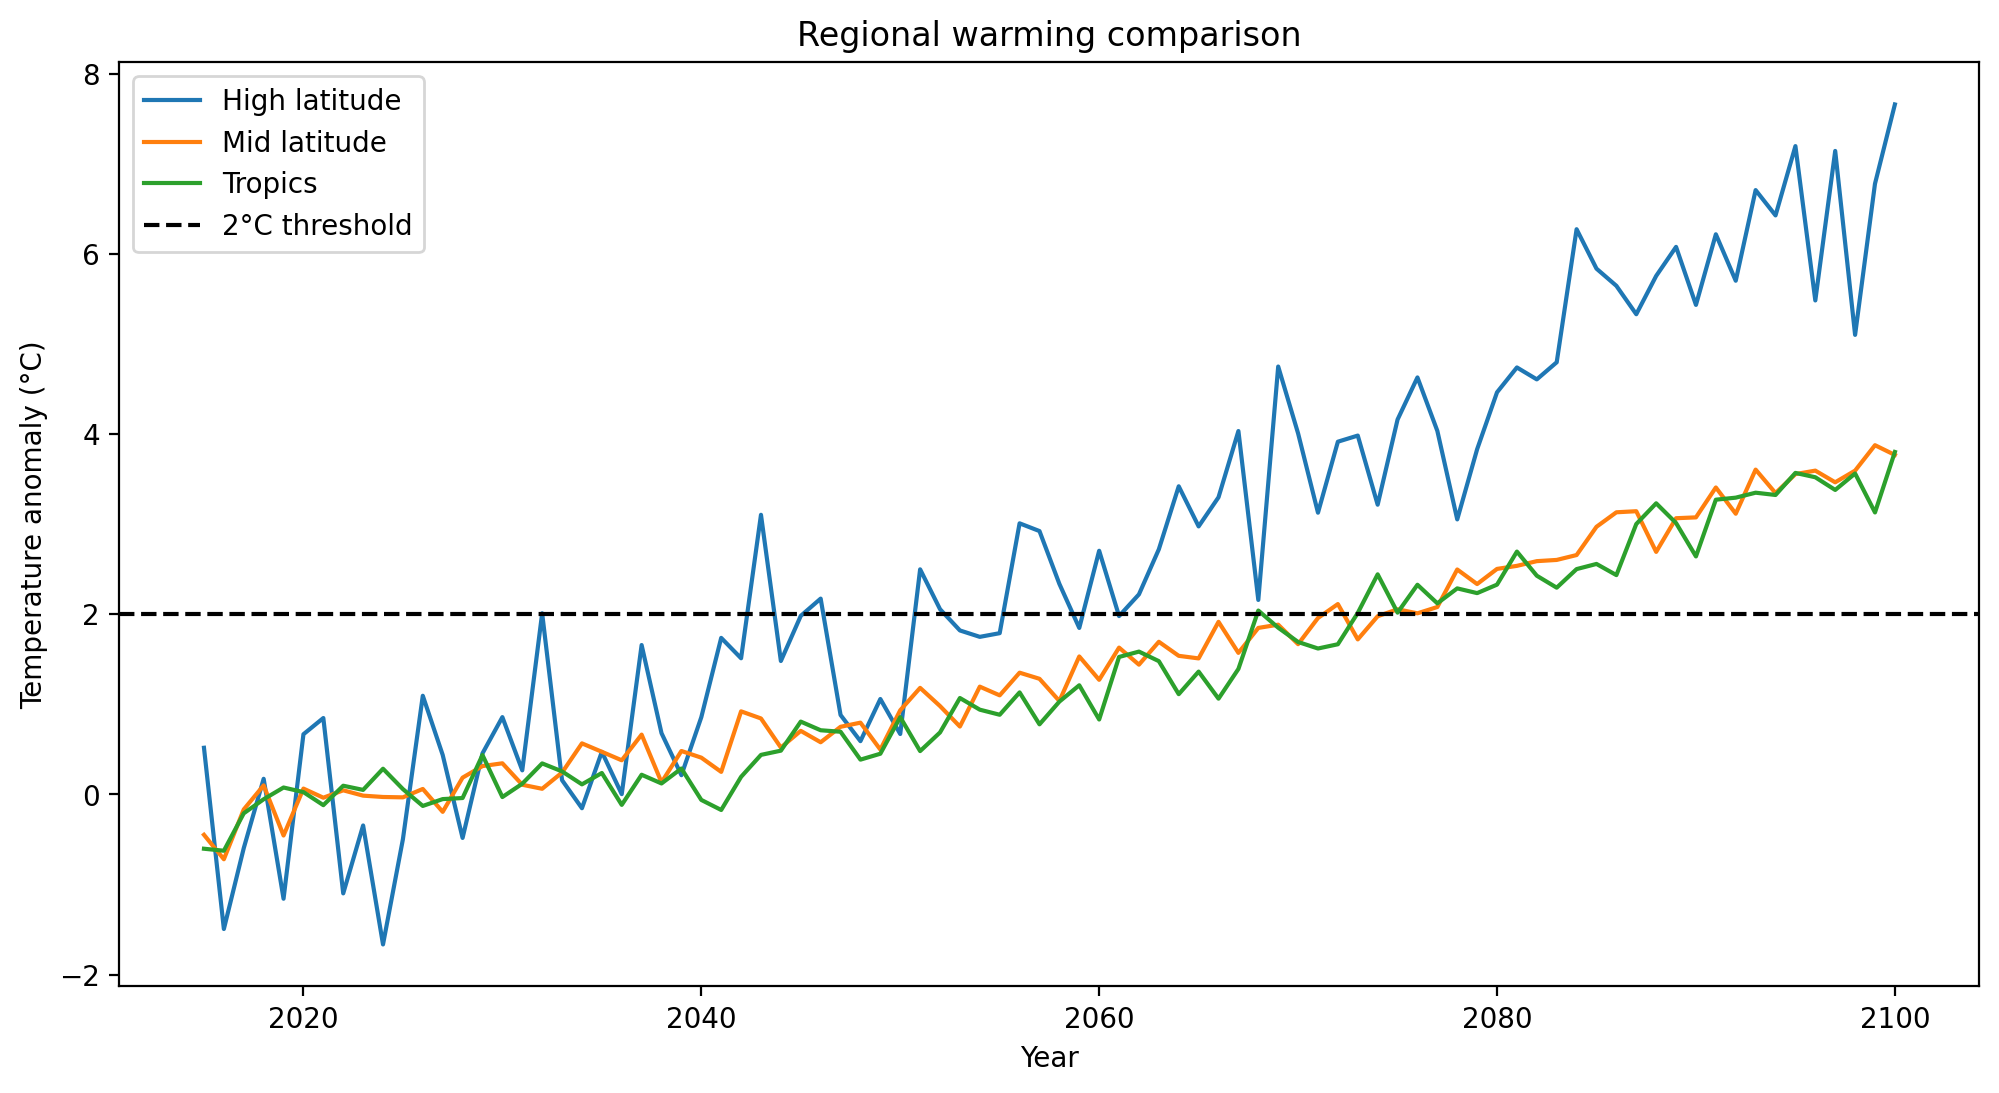

In [17]:
# pick a few locations (indices)
loc1 = tas_yearly[:, 150, 100]  # example
loc2 = tas_yearly[:, 100, 100]
loc3 = tas_yearly[:, 50, 100]

# convert to anomaly
anom = anomaly

plt.plot(anom.year, anom[:, 150, 100], label="High latitude")
plt.plot(anom.year, anom[:, 100, 100], label="Mid latitude")
plt.plot(anom.year, anom[:, 50, 100], label="Tropics")

plt.axhline(2, linestyle="--", color="black", label="2°C threshold")

plt.legend()
plt.title("Regional warming comparison")
plt.xlabel("Year")
plt.ylabel("Temperature anomaly (°C)")
plt.show()

In [ ]:
df_crossing = first_crossing.to_dataframe(name="first_crossing_year").reset_index()

df_crossing.to_csv("data/first_crossing_2C_ssp585.csv", index=False)

df_crossing

,lat,lon,first_crossing_year
0,-90.0,0.00,2041.0
1,-90.0,1.25,2041.0
2,-90.0,2.50,2041.0
3,-90.0,3.75,2041.0
4,-90.0,5.00,2041.0
...,...,...,...
55291,90.0,353.75,2035.0
55292,90.0,355.00,2035.0
55293,90.0,356.25,2035.0
55294,90.0,357.50,2035.0


In [19]:
import numpy as np
for sc in ('ssp126','ssp245','ssp585'):
    subset = catalog.query(
        f"variable_id == 'tas' and table_id == 'Amon' and "
        f"experiment_id == '{sc}' and source_id == 'CESM2'"
    )
    ds = xr.open_zarr(gcs.get_mapper(subset.iloc[0]['zstore']), consolidated=True)
    tas_c = ds['tas'] - 273.15
    yearly = tas_c.groupby('time.year').mean('time')
    baseline = yearly.sel(year=slice(2015, 2034)).mean('year')  # or pre-industrial!
    anomaly = yearly - baseline

    # Save as a single npy
    np.save(f'data/anomaly_{sc}.npy', anomaly.values)  # shape (years, lat, lon)
    np.save('data/lats.npy', yearly.lat.values)
    np.save('data/lons.npy', yearly.lon.values)
    np.save('data/years.npy', yearly.year.values)